# Case Study: Revenue Retention & Customer Lifetime Value Analysis  
## IDALS (Ed-tech Subscription Platform)

IDALS (theidals.com) is an online dance education platform which was operational for 4.10 years (November 2, 2020 - August 31, 2025).
This analysis is based on real transaction-level subscription data covering paid users across multiple plans, durations, and geographies.

### 1. Objective
To understand:
1. How revenue retention behaves over time
2. Which users contribute most to lifetime revenue
3. What behavioral patterns distinguish repeat customers from one-time buyers

This analysis is conducted from a Product & Business decision-making lens, not just exploratory analytics.

In [28]:
import pandas as pd
import numpy as np

In [29]:
df = pd.read_csv('subscribed_users.csv')

In [30]:
df.head()

,Date,Time,Plan,Duration,Fee,Unnamed: 5,Nationality,First Name,Last Name,User ID,...,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,2-Nov-20,21:04,Premium,Monthly,600.0,NaN,National,Tanishka,Kadam,U27,...,9.04.2021,Message sent on whatsapp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3-Nov-20,21:13,Premium,Monthly,600.0,NaN,National,Jiya,Mistry,U124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4-Nov-20,18:27,Premium,Monthly,600.0,NaN,National,vinay,teja,U275,...,9.04.2021,Message sent on whatsapp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4-Nov-20,13:07,Premium,Monthly,600.0,NaN,National,Riddhi,Shukla,U262,...,9.04.2021,Message sent on whatsapp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6-Nov-20,18:37,Premium,Monthly,600.0,NaN,National,Riddhi,ROUSHAN,U36,...,9.04.2021,Message sent on whatsapp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 33 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         2016 non-null   object 
 1   Time         2015 non-null   object 
 2   Plan         2016 non-null   object 
 3   Duration     2016 non-null   object 
 4   Fee          2016 non-null   float64
 5   Unnamed: 5   34 non-null     object 
 6   Nationality  2016 non-null   object 
 7   First Name   1952 non-null   object 
 8   Last Name    1953 non-null   object 
 9   User ID      1951 non-null   object 
 10  Name         1951 non-null   object 
 11  Email ID     2016 non-null   object 
 12  Number       1950 non-null   object 
 13  Place        1950 non-null   object 
 14  Level        1950 non-null   object 
 15  Preference   1432 non-null   object 
 16  Genre        1949 non-null   object 
 17  Motive       1950 non-null   object 
 18  Aim          1942 non-null   object 
 19  Unname

### Unit of Analysis
- Customer is identified using Email ID
- Multiple rows per customer indicate repeat subscriptions
- Each row represents a completed paid transaction

### 2. Data Cleaning

In [32]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\win10\AppData\Local\Temp\ipykernel_27620\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [33]:
df['Email ID'] = df['Email ID'].str.strip().str.lower()

In [34]:
df[['Date', 'Email ID', 'Fee']].isna().sum()

Date        0
Email ID    0
Fee         0
dtype: int64

In [35]:
total_transactions = df.shape[0]
unique_customers = df['Email ID'].nunique()

total_transactions, unique_customers

(2016, 1401)

In [36]:
2016/1401

1.4389721627408993

In [37]:
df = df[['Date', 'Time', 'Plan', 'Duration', 'Fee', 'Nationality', 'Email ID']]
df.head()

,Date,Time,Plan,Duration,Fee,Nationality,Email ID
0,2020-11-02,21:04,Premium,Monthly,600.0,National,kiran.kadam_11@yahoo.com
1,2020-11-03,21:13,Premium,Monthly,600.0,National,jiyamistry3103@gmail.com
2,2020-11-04,18:27,Premium,Monthly,600.0,National,vinayteja19@gmail.com
3,2020-11-04,13:07,Premium,Monthly,600.0,National,aman895980@gmail.com
4,2020-11-06,18:37,Premium,Monthly,600.0,National,roushanrajesh80@gmail.com


In [38]:
df['Nationality'] = df['Nationality'].str.strip().str.title()
df['Nationality'].value_counts()

Nationality
National         1900
International     116
Name: count, dtype: int64

### Dataset Overview (Post Cleaning)
- Total paid transactions: 2016
- Unique customers (by email): 1401
- Average subscriptions per customer: 2016/1401 = 1.43

### 3. First Purchase Date

In [40]:
# First purchase date per customer

first_purchase = df.groupby('Email ID')['Date'].min().reset_index().rename(columns={'Date': 'First_Purchase_Date'})
first_purchase.head()

,Email ID,First_Purchase_Date
0,03101974pravin@gmail.com,2022-07-14
1,04shankar12@gmail.com,2021-03-20
2,100whitemoney@gmail.com,2021-03-03
3,1205vishnu@gmail.com,2025-01-12
4,125crewindia@gmail.com,2021-12-27


In [41]:
df = df.merge(first_purchase, on='Email ID', how='left')
df[['Email ID', 'Date', 'First_Purchase_Date']].head()

,Email ID,Date,First_Purchase_Date
0,kiran.kadam_11@yahoo.com,2020-11-02,2020-11-02
1,jiyamistry3103@gmail.com,2020-11-03,2020-11-03
2,vinayteja19@gmail.com,2020-11-04,2020-11-04
3,aman895980@gmail.com,2020-11-04,2020-11-04
4,roushanrajesh80@gmail.com,2020-11-06,2020-11-06


In [42]:
df['Customer_Age_Days'] = (df['Date'] - df['First_Purchase_Date']).dt.days
df['Customer_Age_Months'] = (df['Customer_Age_Days']/30).astype(int)

In [44]:
df.sort_values(['Email ID', 'Date']).head(20)

,Date,Time,Plan,Duration,Fee,Nationality,Email ID,First_Purchase_Date,Customer_Age_Days,Customer_Age_Months
1263,2022-07-14,11:00,Full Access,Weekly,400.000,National,03101974pravin@gmail.com,2022-07-14,0,0
196,2021-03-20,12:08,Standard,Monthly,500.000,National,04shankar12@gmail.com,2021-03-20,0,0
309,2021-05-04,21:32,Standard,Monthly,700.000,National,04shankar12@gmail.com,2021-03-20,45,1
150,2021-03-03,20:15,Premium,Monthly,600.000,National,100whitemoney@gmail.com,2021-03-03,0,0
1905,2025-01-12,9:46,Full Access,Weekly,826.464,International,1205vishnu@gmail.com,2025-01-12,0,0
827,2021-12-27,7:18,Full Access,Weekly,200.000,National,125crewindia@gmail.com,2021-12-27,0,0
1247,2022-07-13,22:46,Full Access,Monthly,840.000,National,1304ashwani@gmail.com,2022-07-13,0,0
1130,2022-04-29,20:12,Full Access,Monthly,168.000,National,17chend.bhavar@ug.ictmumbai.edu.in,2022-04-29,0,0
172,2021-03-10,17:36,Premium,Monthly,600.000,National,1987darsh@gmail.com,2021-03-10,0,0
1029,2022-04-07,10:17,Full Access,Monthly,840.000,National,1987darsh@gmail.com,2021-03-10,393,13


### Customer Time Normalization
- To analyze retention and lifetime value meaningfully, all transactions were aligned to each customer's first purchase date.
- This allows comparison of user behavior relative to their entry point, rather than calendar time.

In [45]:
df['Customer_Age_Months'].max()

53

### 4. Revenue Based Retention

In [46]:
# Revenue at each customer age month

revenue_by_age = (df.groupby('Customer_Age_Months')['Fee'].sum().reset_index().sort_values('Customer_Age_Months'))
revenue_by_age.head()

,Customer_Age_Months,Fee
0,0,1221709.182
1,1,97340.674
2,2,50993.570
3,3,27228.700
4,4,35154.930


In [47]:
df['Fee'].sum()

np.float64(1754703.6940000001)

In [48]:
# Convert to revenue retention %
month_0_revenue = revenue_by_age.loc[revenue_by_age['Customer_Age_Months'] == 0, 'Fee'].values[0]

revenue_by_age['Revenue_Retention_%'] = (revenue_by_age['Fee'] / month_0_revenue) * 100

revenue_by_age.head(10)

,Customer_Age_Months,Fee,Revenue_Retention_%
0,0,1221709.182,100.000000
1,1,97340.674,7.967581
2,2,50993.570,4.173953
3,3,27228.700,2.228738
4,4,35154.930,2.877520
5,5,38372.080,3.140852
6,6,24642.340,2.017038
7,7,21680.000,1.774563
8,8,21069.374,1.724582
9,9,19655.600,1.608861


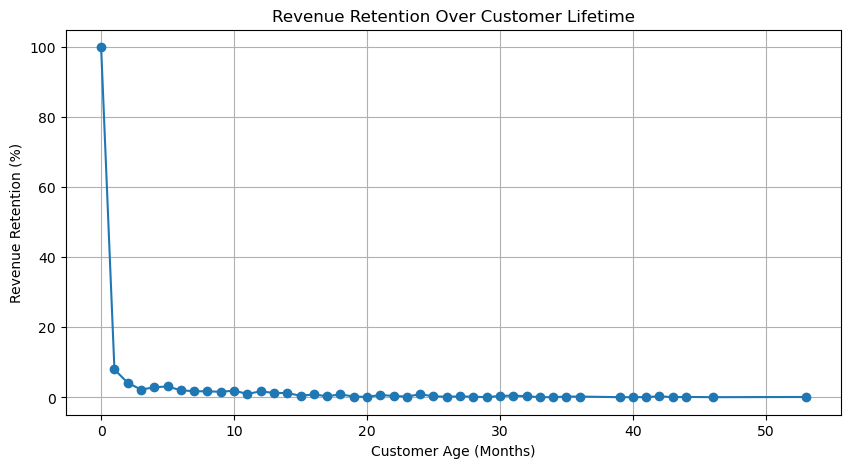

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(revenue_by_age['Customer_Age_Months'], revenue_by_age['Revenue_Retention_%'], marker='o')

plt.title('Revenue Retention Over Customer Lifetime')
plt.xlabel('Customer Age (Months)')
plt.ylabel('Revenue Retention (%)')
plt.grid(True)
plt.show()

- Initial purchase accounts for the majority of revenue, which is expected for an education subscription model. However, the long-tail revenue retention extending beyond 50 months indicates a loyal core segment contributing sustained lifetime value.

In [50]:
revenue_by_age.head(30)

,Customer_Age_Months,Fee,Revenue_Retention_%
0,0,1221709.182,100.000000
1,1,97340.674,7.967581
2,2,50993.570,4.173953
3,3,27228.700,2.228738
4,4,35154.930,2.877520
5,5,38372.080,3.140852
6,6,24642.340,2.017038
7,7,21680.000,1.774563
8,8,21069.374,1.724582
9,9,19655.600,1.608861


In [51]:
df[df['Customer_Age_Months'] > 0]['Email ID'].nunique()

306

- 306 of them were actually repeated users.

### Revenue Retention Interpretation

- The majority of revenue is generated at the time of first purchase (Month 0), which is expected for an ed-tech subscription model where users typically pay upfront for a plan or duration.
- Revenue drops sharply after the first month because only a subset of users choose to renew or purchase again. However, revenue does not fall to zero. A small but consistent amount of revenue continues to be generated across many months, extending beyond 4 years (50+ months).
- Out of 1,401 unique customers, 306 users made repeat purchases. This indicates the presence of a loyal core user segment that contributes to long-term revenue.
- The revenue retention curve shows a long-tail pattern, suggesting that while most users are one-time buyers, a smaller group of engaged users continues to return and generate value over time.
- This behavior highlights the importance of retention-focused strategies, as improving repeat purchase behavior among this core segment could have a meaningful impact on overall lifetime value.
- Rather than optimizing only for new customer acquisition, this analysis suggests that strengthening engagement and renewal journeys for repeat users could deliver higher returns.

### 5. Identifying High-Value Users

In [59]:
# Total revenue (LTV) per user

customer_ltv = df.groupby('Email ID')['Fee'].sum().reset_index().rename(columns={'Fee': 'Total_Revenue'})

In [60]:
customer_ltv.head(20)

,Email ID,Total_Revenue
0,03101974pravin@gmail.com,400.000
1,04shankar12@gmail.com,1200.000
2,100whitemoney@gmail.com,600.000
3,1205vishnu@gmail.com,826.464
4,125crewindia@gmail.com,200.000
5,1304ashwani@gmail.com,840.000
6,17chend.bhavar@ug.ictmumbai.edu.in,168.000
7,1987darsh@gmail.com,3120.000
8,20ec01008@iitbbs.ac.in,840.000
9,22ritu23@gmail.com,1408.000


In [61]:
# Number of times each user purchased

purchase_counts = df.groupby('Email ID').size().reset_index(name='Total_Purchases')

customer_ltv = customer_ltv.merge(purchase_counts, on='Email ID')

In [62]:
customer_ltv.head(20)

,Email ID,Total_Revenue,Total_Purchases
0,03101974pravin@gmail.com,400.000,1
1,04shankar12@gmail.com,1200.000,2
2,100whitemoney@gmail.com,600.000,1
3,1205vishnu@gmail.com,826.464,1
4,125crewindia@gmail.com,200.000,1
5,1304ashwani@gmail.com,840.000,1
6,17chend.bhavar@ug.ictmumbai.edu.in,168.000,1
7,1987darsh@gmail.com,3120.000,4
8,20ec01008@iitbbs.ac.in,840.000,1
9,22ritu23@gmail.com,1408.000,3


In [63]:
# Classifying users

def customer_segment(purchases):
    if purchases == 1:
        return 'One-Time Buyer'
    elif purchases == 2:
        return 'Repeat Buyer'
    else:
        return 'High-Value Buyer'

customer_ltv['Customer_Segment'] = customer_ltv['Total_Purchases'].apply(customer_segment)

In [64]:
customer_ltv['Customer_Segment'].value_counts()

Customer_Segment
One-Time Buyer      1075
Repeat Buyer         204
High-Value Buyer     122
Name: count, dtype: int64

In [66]:
# Average total revenue per customer segment

avg_revenue_by_segment = customer_ltv.groupby('Customer_Segment')['Total_Revenue'].mean().reset_index(name='Average_Revenue')
avg_revenue_by_segment

,Customer_Segment,Average_Revenue
0,High-Value Buyer,3749.342246
1,One-Time Buyer,882.719137
2,Repeat Buyer,1707.651314


In [71]:
segment_summary = (
    customer_ltv
    .groupby('Customer_Segment')
    .agg(
        Customers=('Email ID', 'count'),
        Avg_Total_Revenue=('Total_Revenue', 'mean'),
        Median_Total_Revenue=('Total_Revenue', 'median')
    )
    .reset_index()
)

segment_summary

,Customer_Segment,Customers,Avg_Total_Revenue,Median_Total_Revenue
0,High-Value Buyer,122,3749.342246,2560.0
1,One-Time Buyer,1075,882.719137,700.0
2,Repeat Buyer,204,1707.651314,1400.0


### Revenue Contribution by Customer Segment

- Customers were grouped based on how many times they purchased on the platform.
- One-Time Buyers form the largest segment (1,075 customers), but they generate the lowest revenue per customer. On average, a One-Time Buyer contributes ₹883 in total revenue, with a median value of ₹700.
- Repeat Buyers (204 customers) show a clear increase in value. Their average total revenue is ₹1,708, nearly double that of One-Time Buyers, indicating that even one additional purchase significantly increases lifetime value.
- High-Value Buyers represent the smallest group (122 customers) but generate the highest revenue per customer. On average, a High-Value Buyer contributes ₹3,749 in total revenue, with a median value of ₹2,560.
- This analysis shows that a small group of repeat and high-value customers contributes disproportionately more revenue compared to one-time buyers, highlighting the importance of retention and repeat engagement in driving long-term business value.

### 6. Revenue Concentration

In [73]:
total_revenue = customer_ltv['Total_Revenue'].sum()
print(total_revenue)

1754703.6940000001


In [74]:
# Revenue share by each customer segment

revenue_by_segment = (
    customer_ltv
    .groupby('Customer_Segment')['Total_Revenue']
    .sum()
    .reset_index()
)

revenue_by_segment['Revenue_%'] = (
    revenue_by_segment['Total_Revenue'] / total_revenue
) * 100

revenue_by_segment

,Customer_Segment,Total_Revenue,Revenue_%
0,High-Value Buyer,457419.754,26.068205
1,One-Time Buyer,948923.072,54.078821
2,Repeat Buyer,348360.868,19.852974


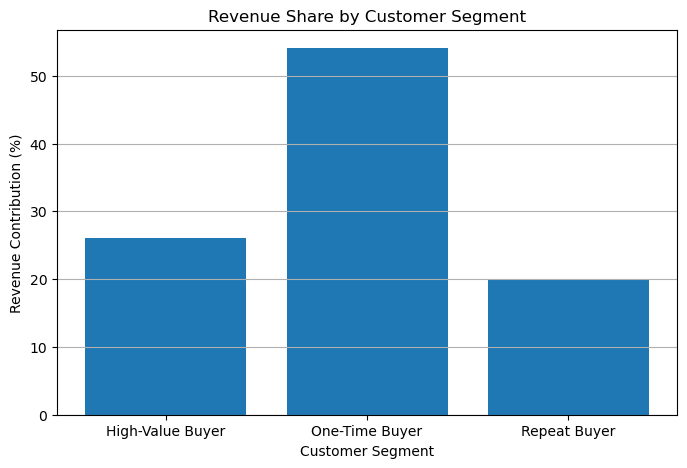

In [75]:
plt.figure(figsize=(8,5))
plt.bar(revenue_by_segment['Customer_Segment'], revenue_by_segment['Revenue_%'])

plt.title('Revenue Share by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue Contribution (%)')
plt.grid(axis='y')
plt.show()

### Revenue Concentration Across Customer Segments

- The platform generated a gross total revenue of ₹17.5 lakhs from paid subscriptions.
- One-Time Buyers account for the largest share of users and contribute the highest portion of total revenue (54%). However, this revenue is distributed across a very large number of customers, resulting in lower revenue per customer.
- Repeat Buyers contribute nearly 20% of total revenue, despite being a much smaller group. This indicates that even a second purchase significantly increases a customer’s lifetime value.
- High-Value Buyers represent the smallest segment of users, yet they contribute over 26% of total revenue. This highlights a strong concentration of revenue among customers who make multiple repeat purchases.
- Overall, nearly 46% of total revenue comes from customers who purchased more than once. This suggests that improving retention and repeat purchase behavior could have a meaningful impact on revenue growth, potentially more than increasing one-time acquisitions alone.

### 7. Cohort-Based LTV

In [76]:
# The month in which a customer made their first purchase

df['First_Purchase_Month'] = df['First_Purchase_Date'].dt.to_period('M')

In [77]:
df[['Email ID', 'First_Purchase_Date', 'First_Purchase_Month']].head()

,Email ID,First_Purchase_Date,First_Purchase_Month
0,kiran.kadam_11@yahoo.com,2020-11-02,2020-11
1,jiyamistry3103@gmail.com,2020-11-03,2020-11
2,vinayteja19@gmail.com,2020-11-04,2020-11
3,aman895980@gmail.com,2020-11-04,2020-11
4,roushanrajesh80@gmail.com,2020-11-06,2020-11


In [78]:
df[['Email ID', 'First_Purchase_Date', 'First_Purchase_Month']].tail()

,Email ID,First_Purchase_Date,First_Purchase_Month
2011,curlygirl10222@gmail.com,2025-08-12,2025-08
2012,iamsantastic@gmail.com,2024-08-24,2024-08
2013,kulayenreshmaguddi@gmail.com,2025-08-19,2025-08
2014,agarwaltanvi2007@gmail.com,2025-08-26,2025-08
2015,abhirudeboy@gmail.com,2025-08-27,2025-08


### Cohort Definition

- Customers are grouped into cohorts based on the month of their first paid subscription.
- This allows comparison of lifetime value and retention behavior across different customer entry periods.

In [79]:
# Cohort revenue table
cohort_revenue = df.groupby(['First_Purchase_Month', 'Customer_Age_Months'])['Fee'].sum().reset_index()

cohort_revenue.head()

,First_Purchase_Month,Customer_Age_Months,Fee
0,2020-11,0,9300.0
1,2020-11,1,4200.0
2,2020-11,2,1700.0
3,2020-11,3,1200.0
4,2020-11,4,6360.0


In [80]:
cohort_ltv = cohort_revenue.pivot_table(
    index='First_Purchase_Month',
    columns='Customer_Age_Months',
    values='Fee'
)

cohort_ltv.head()

Customer_Age_Months,0,1,2,3,4,5,6,7,8,9,...,35,36,39,40,41,42,43,44,46,53
First_Purchase_Month,,,,,,,,,,,,,,,,,,,,,
2020-11,9300.00,4200.00,1700.00,1200.0,6360.0,12440.0,840.00,NaN,700.0,1240.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1440.0
2020-12,8100.00,2400.00,2200.00,1300.0,NaN,6600.0,1540.00,NaN,1680.0,840.0,...,NaN,NaN,NaN,600.0,NaN,NaN,NaN,NaN,NaN,NaN
2021-01,27168.12,3781.69,2240.00,1540.0,2380.0,1680.0,2795.14,840.0,NaN,840.0,...,NaN,NaN,NaN,NaN,NaN,840.0,NaN,400.0,NaN,NaN
2021-02,28574.79,4180.00,5871.19,700.0,NaN,NaN,840.00,NaN,4586.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.0,NaN
2021-03,40521.00,7905.98,6540.00,700.0,NaN,NaN,400.00,840.0,840.0,1640.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
cohort_ltv_cumulative = cohort_ltv.cumsum(axis=1)

cohort_ltv_cumulative.head()

Customer_Age_Months,0,1,2,3,4,5,6,7,8,9,...,35,36,39,40,41,42,43,44,46,53
First_Purchase_Month,,,,,,,,,,,,,,,,,,,,,
2020-11,9300.00,13500.00,15200.00,16400.00,22760.00,35200.00,36040.00,NaN,36740.00,37980.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50668.0
2020-12,8100.00,10500.00,12700.00,14000.00,NaN,20600.00,22140.00,NaN,23820.00,24660.00,...,NaN,NaN,NaN,28508.0,NaN,NaN,NaN,NaN,NaN,NaN
2021-01,27168.12,30949.81,33189.81,34729.81,37109.81,38789.81,41584.95,42424.95,NaN,43264.95,...,NaN,NaN,NaN,NaN,NaN,49600.95,NaN,50000.95,NaN,NaN
2021-02,28574.79,32754.79,38625.98,39325.98,NaN,NaN,40165.98,NaN,44751.98,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56197.81,NaN
2021-03,40521.00,48426.98,54966.98,55666.98,NaN,NaN,56066.98,56906.98,57746.98,59386.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cohort LTV Matrix

- The table below shows cumulative revenue generated by each customer cohort over time.
- Each row represents customers who made their first purchase in a given month and each column shows how revenue accumulates as those customers age.
- This view helps identify which cohorts generate sustained value over time and whether customer quality has improved or declined across periods.

- Each row in the table represents customers who made their first purchase in a specific month, and the values show how cumulative revenue from those customers increased over time.
- Early cohorts, particularly from late 2020 and early 2021, continue to generate revenue even several years after their first purchase. This indicates the presence of long-term users who return and contribute to revenue over extended periods.
- Across most cohorts, revenue grows rapidly in the first few months and then increases more gradually. This suggests that repeat purchases are more likely to happen earlier in a customer’s lifecycle, with a smaller group continuing to engage in the long term.
- The differences in growth patterns across cohorts show that not all customer groups behave the same way. Some cohorts generate sustained value over time, while others plateau earlier. This highlights the importance of understanding what drives higher-quality cohorts and designing product strategies to replicate that behavior.

### Key Problems Identified

1. Most users purchase only once and do not return, leading to a sharp drop in revenue after the first purchase.
2. A small group of repeat and high-value users generates a disproportionately large share of long-term revenue.
3. Most repeat purchases occur within the first few months after the initial purchase, after which engagement slows.
4. Cohort behavior varies, suggesting differences in user quality or onboarding effectiveness across time.

### Strategy 1: Improve Second Purchase Conversion

The largest opportunity lies in converting one-time buyers into repeat buyers.

Product actions could include:
- Clear renewal prompts near the end of a plan
- Personalized recommendations based on the user’s first purchase
- Time-bound offers for a second subscription within the first 60–90 days

Even a small improvement in second-purchase conversion could significantly increase overall revenue.

### Strategy 2: Strengthen Early Lifecycle Engagement

Since repeat purchases tend to happen early, the first few months of the customer journey are critical.

Potential improvements include:
- Better onboarding to help users see value quickly
- Progress-based nudges encouraging continued learning
- Timely reminders when users approach course completion

Improving early engagement increases the likelihood of users returning for additional subscriptions.

### Strategy 3: Retain and Reward High-Value Users

High-value buyers represent a small but critical segment of the business.

Product initiatives could include:
- Early access to new programs
- Loyalty benefits or bundled pricing
- Direct feedback loops to understand their needs

Retaining these users is often more cost-effective than acquiring new ones.

### Data-Informed and AI-Led Opportunities

Based on historical data, a simple predictive model could estimate the likelihood of a customer making a repeat purchase using signals such as:
- First plan type
- Subscription duration
- Fee paid
- Nationality and location

This prediction could be used to trigger targeted retention interventions, improving lifetime value without increasing acquisition spend.

### Conclusion

This analysis shows that long-term revenue is driven not by the number of users acquired, but by the ability to retain and re-engage a smaller set of committed users.

By focusing on early engagement, second-purchase conversion and retention of high-value customers, an ed-tech subscription platform can meaningfully improve lifetime value and revenue sustainability.